# EEG · Causal Conv1D — Multi-Trial, Fixed Architecture

Trains on **trials 0–7** with a **fixed** causal Conv1D architecture (no hyperparameter search).  
Evaluates via **Leave-One-Trial-Out (LOTO) CV**, then reports final performance on the truly  
held-out **trials 8 & 9**.

```
Window [i-T : i]  →  CausalConv1D  →  P(eye open at i)
```

| Step | Details |
|---|---|
| Normalisation | Per-window z-score per channel (no global scaler) |
| CV | LeaveOneGroupOut by trial ID |
| Threshold | Youden's J on LOTO holdout probabilities |
| Test | Trials 8 & 9, never seen during training |

In [1]:
import sys
sys.path.insert(0, "..")

import warnings

warnings.filterwarnings("ignore")
import os

import matplotlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from mne.filter import filter_data
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import LeaveOneGroupOut
from torch.utils.data import DataLoader, TensorDataset

matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from src.preprocessing import load_trial, build_windows

DARK = "#0a0e17"
CARD = "#111827"
EDGE = "#1f2937"
TEAL = "#00e5cc"
CORAL = "#ff4f5e"
GOLD = "#ffc947"
LIME = "#a8ff3e"
WHITE = "#f0f4ff"
GRAY = "#6b7280"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device : {DEVICE}")
print("All imports OK.")

Device : mps
All imports OK.


## 1 · Configuration

All hyperparameters are defined here. Edit this cell to experiment.

In [2]:
FS        = 250
SUBJECT   = 0
TACHE     = "spt"
DATA_PATH = f"../data/subject{SUBJECT}/"

TRAIN_TRIALS = list(range(8))  # 0–7  →  LOTO CV
TEST_TRIALS  = [8, 9]          # truly held out

# ── Fixed window size ──────────────────────────────────────────────────────
T = 44    # samples  →  176 ms at 250 Hz

# ── Fixed CNN architecture ─────────────────────────────────────────────────
N_LAYERS     = 5
N_FILTERS    = 60     # grows each layer: 60→120→240→256→256 (capped at 256)
KERNEL_SIZE  = 3
GROW_FILTERS = True
DROPOUT      = 0.3
ACTIVATION   = "relu"  # relu | elu | gelu
USE_BN       = True

# ── Training ───────────────────────────────────────────────────────────────
OPTIMIZER    = "adamw"   # adamw | adam | sgd
LR           = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 256
MAX_EPOCHS   = 60
PATIENCE     = 10        # early stopping (val AUC); set = MAX_EPOCHS to disable

APPLY_CLEANING = False

print(f"Train trials : {TRAIN_TRIALS}")
print(f"Test  trials : {TEST_TRIALS}")
print(f"Window T     : {T} samples = {T/FS*1000:.0f} ms")
print(f"Architecture : {N_LAYERS} layers, {N_FILTERS} filters "
      f"(grow={GROW_FILTERS}), kernel={KERNEL_SIZE}")
print(f"Training     : {OPTIMIZER}  lr={LR}  epochs={MAX_EPOCHS}  patience={PATIENCE}")

Train trials : [0, 1, 2, 3, 4, 5, 6, 7]
Test  trials : [8, 9]
Window T     : 44 samples = 176 ms
Architecture : 5 layers, 60 filters (grow=True), kernel=3
Training     : adamw  lr=0.001  epochs=60  patience=10


## 2 · Load & Preprocess All Trials

Each trial is band-pass filtered (0.1–60 Hz) independently, then concatenated  
with a `trial_id` group label that prevents cross-trial windows in LOTO CV.

In [3]:
print("Helper functions loaded from src.preprocessing.")

Helper functions loaded from src.preprocessing.


In [4]:
print("Loading train trials …")
EEG_COLS = None
X_parts, y_parts, g_parts = [], [], []

for t in TRAIN_TRIALS:
    df, cols = load_trial(SUBJECT, TACHE, t, DATA_PATH, eeg_cols=EEG_COLS, car=True)
    if EEG_COLS is None:
        EEG_COLS = cols
    X_parts.append(df[EEG_COLS].values.astype(np.float32))
    y_parts.append(df["button"].values.astype(int))
    g_parts.append(np.full(len(df), t, dtype=np.int64))
    bal = df["button"].value_counts().to_dict()
    print(f"  trial {t}: {len(df):>6,} samples  label={bal}")

X_train_raw = np.concatenate(X_parts, axis=0)
y_train_raw = np.concatenate(y_parts, axis=0)
g_train_raw = np.concatenate(g_parts, axis=0)

N_CHANNELS = len(EEG_COLS)
print(f"\nCombined train : {X_train_raw.shape}")
print(f"Channels       : {N_CHANNELS}  {EEG_COLS}")
print(f"Class balance  : {dict(zip(*np.unique(y_train_raw, return_counts=True)))}")

Loading train trials …
Setting up band-pass filter from 0.5 - 8 Hz


FIR filter parameters


---------------------


Designing a one-pass, zero-phase, non-causal bandpass filter:


- Windowed time-domain design (firwin) method


...

- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)


- Upper passband edge: 8.00 Hz


- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)


- Filter length: 1651 samples (6.604 s)


  trial 7: 16,459 samples  label={0: 13973, 1: 2486}

Combined train : (119840, 16)
Channels       : 16  ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']
Class balance  : {np.int64(0): np.int64(98133), np.int64(1): np.int64(21707)}


In [5]:
print("Loading test trials …")
X_test_parts, y_test_parts, g_test_parts = [], [], []

for t in TEST_TRIALS:
    df_t, _ = load_trial(SUBJECT, TACHE, t, DATA_PATH, eeg_cols=EEG_COLS, car=True)
    X_test_parts.append(df_t[EEG_COLS].values.astype(np.float32))
    y_test_parts.append(df_t["button"].values.astype(int))
    g_test_parts.append(np.full(len(df_t), t, dtype=np.int64))
    bal = df_t["button"].value_counts().to_dict()
    print(f"  trial {t}: {len(df_t):>6,} samples  label={bal}")

X_test_raw = np.concatenate(X_test_parts, axis=0)
y_test_raw = np.concatenate(y_test_parts, axis=0)
g_test_raw = np.concatenate(g_test_parts, axis=0)
print(f"\nCombined test  : {X_test_raw.shape}")

Loading test trials …


Setting up band-pass filter from 0.5 - 8 Hz


FIR filter parameters


---------------------


Designing a one-pass, zero-phase, non-causal bandpass filter:


...

- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)


- Upper passband edge: 8.00 Hz


- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)


- Filter length: 1651 samples (6.604 s)


  trial 9: 16,020 samples  label={0: 14046, 1: 1974}

Combined test  : (33904, 16)


## 3 · Build Windowed Dataset

Window each trial into overlapping causal windows of length **T**.  
Windows that would span two trial boundaries are skipped to prevent leakage.

In [6]:
X_win, y_win, g_win = build_windows(X_train_raw, y_train_raw, T, groups=g_train_raw)
X_torch = torch.tensor(X_win)
y_torch = torch.tensor(y_win)

print(f"Train windows : {X_win.shape}   labels : {y_win.shape}")
print(f"Unique trials : {np.unique(g_win)}")
print(f"Class balance : {dict(zip(*np.unique(y_win, return_counts=True)))}")

Train windows : (119488, 16, 44)   labels : (119488,)
Unique trials : [0 1 2 3 4 5 6 7]
Class balance : {np.int64(0): np.int64(97781), np.int64(1): np.int64(21707)}


## 4 · Causal Conv1D Architecture

```
Input  (batch, C, T)
  │
  ├─ Conv1d(C → F, k) + causal padding + Trim + BN + ReLU + Dropout
  ├─ Conv1d(F → 2F, k) + ...          (if GROW_FILTERS)
  └─ Conv1d(2F → 4F, k) + ...
        │
  AdaptiveAvgPool1d(1)  →  (batch, last_F)
        │
  Linear → scalar logit  →  sigmoid → P(open)
```

Causal padding: pad `kernel_size - 1` on the **left** then trim the right,  
so prediction at time `t` only sees samples ≤ `t`.

In [7]:
class _Trim(nn.Module):
    """Remove n timesteps from the right (enforces causal output)."""

    def __init__(self, n):
        super().__init__()
        self.n = n

    def forward(self, x):
        return x[..., : -self.n] if self.n > 0 else x


class CausalConv1D(nn.Module):
    _ACTS = {
        "relu": nn.ReLU,
        "elu": nn.ELU,
        "gelu": nn.GELU,
        "leaky_relu": nn.LeakyReLU,
    }

    def __init__(
        self,
        in_channels,
        n_filters,
        n_layers,
        kernel_size,
        grow_filters,
        dropout_rate,
        activation,
        use_bn,
    ):
        super().__init__()
        Act = self._ACTS[activation]
        layers, in_ch = [], in_channels

        for i in range(n_layers):
            out_ch = min(n_filters * (2**i) if grow_filters else n_filters, 256)
            padding = kernel_size - 1
            layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
                _Trim(padding),
            ]
            if use_bn:
                layers.append(nn.BatchNorm1d(out_ch))
            layers.append(Act())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_ch = out_ch

        self.conv_stack = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(in_ch, 1)

    def forward(self, x):  # x: (B, C, T)
        x = self.conv_stack(x)  # (B, last_ch, T)
        return self.head(self.pool(x).squeeze(-1)).squeeze(1)  # (B,)


def make_model():
    """Instantiate a CausalConv1D with the fixed config from section 1."""
    return CausalConv1D(
        in_channels=N_CHANNELS,
        n_filters=N_FILTERS,
        n_layers=N_LAYERS,
        kernel_size=KERNEL_SIZE,
        grow_filters=GROW_FILTERS,
        dropout_rate=DROPOUT,
        activation=ACTIVATION,
        use_bn=USE_BN,
    )


# Sanity check
_m = make_model()
_x = torch.randn(8, N_CHANNELS, T)
print(f"Input  : {_x.shape}  →  Output : {_m(_x).shape}")
print(f"Params : {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x

Input  : torch.Size([8, 16, 44])  →  Output : torch.Size([8])
Params : 494,861


## 5 · Training Helpers

In [8]:
@torch.no_grad()
def predict_proba(model, X_t, batch_size=512):
    model.eval()
    loader = DataLoader(
        TensorDataset(X_t, torch.zeros(len(X_t))), batch_size=batch_size
    )
    return torch.cat(
        [torch.sigmoid(model(xb.to(DEVICE))).cpu() for xb, _ in loader]
    ).numpy()


def run_fold(X_tr_t, y_tr_t, X_va_t, y_va_t, max_epochs=None, patience=None):
    """
    Train one fold of CausalConv1D using the fixed config.

    Returns (best_val_auc, best_probs_on_val, val_auc_history, best_model).
    """
    if max_epochs is None:
        max_epochs = MAX_EPOCHS
    if patience is None:
        patience = PATIENCE

    pw = (
        torch.tensor([(y_tr_t == 0).sum() / max((y_tr_t == 1).sum(), 1)])
        .float()
        .to(DEVICE)
    )
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    model = make_model().to(DEVICE)

    if OPTIMIZER == "adamw":
        opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    elif OPTIMIZER == "sgd":
        opt = torch.optim.SGD(
            model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, momentum=0.9
        )
    else:
        opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t.float()), batch_size=BATCH_SIZE, shuffle=True
    )

    best_auc, best_probs, best_state, no_improve = 0.0, None, None, 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        scheduler.step()

        probs = predict_proba(model, X_va_t)
        auc = roc_auc_score(y_va_t.numpy(), probs)
        history.append(auc)

        if auc > best_auc:
            best_auc = auc
            best_probs = probs.copy()
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    best_model = make_model()
    best_model.load_state_dict(best_state)
    best_model = best_model.to(DEVICE)
    return best_auc, best_probs, history, best_model


print("Training helpers defined.")

Training helpers defined.


## 6 · Leave-One-Trial-Out CV

Each fold trains on 7 trials and validates on the remaining 1.  
This gives unbiased out-of-trial predictions across all 8 train trials,  
which are then used to compute the optimal decision threshold.

In [9]:
logo = LeaveOneGroupOut()

loto_aucs  = []
all_probs  = np.zeros(len(y_win), dtype=np.float32)
all_preds  = np.full(len(y_win), -1, dtype=int)
train_hists = []

for held_trial, (tr_idx, va_idx) in zip(
    np.unique(g_win), logo.split(X_win, y_win, groups=g_win)
):
    auc, probs, hist, _ = run_fold(
        X_torch[tr_idx], y_torch[tr_idx],
        X_torch[va_idx], y_torch[va_idx],
    )
    all_probs[va_idx] = probs
    all_preds[va_idx] = (probs >= 0.5).astype(int)   # provisional
    loto_aucs.append(auc)
    train_hists.append(hist)
    print(f"  held={held_trial}  AUC={auc:.4f}  epochs={len(hist)}")

mask = all_preds >= 0
print(f"\nLOTO mean AUC : {np.mean(loto_aucs):.4f} ± {np.std(loto_aucs):.4f}")

  held=0  AUC=0.4984  epochs=20


  held=1  AUC=0.5360  epochs=15


  held=2  AUC=0.5921  epochs=11


  held=3  AUC=0.5357  epochs=12


  held=4  AUC=0.5159  epochs=11


  held=5  AUC=0.5429  epochs=42


  held=6  AUC=0.5838  epochs=11


  held=7  AUC=0.6325  epochs=16

LOTO mean AUC : 0.5547 ± 0.0416


## 7 · Optimal Threshold (Youden's J)

Find the decision threshold that maximises `TPR − FPR` on the LOTO holdout  
probabilities (the only unbiased estimate of out-of-trial performance).

In [10]:
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_win[mask], all_probs[mask])
best_thresh = float(thresholds_cv[np.argmax(tpr_cv - fpr_cv)])

preds_opt = (all_probs >= best_thresh).astype(int)
acc_opt   = (preds_opt[mask] == y_win[mask]).mean()

print(f"Optimal threshold (Youden's J) : {best_thresh:.3f}")
print(f"LOTO accuracy @ optimal thresh : {acc_opt:.4f}")
print()
print(classification_report(y_win[mask], preds_opt[mask],
                             target_names=["Closed", "Open"]))

Optimal threshold (Youden's J) : 0.541
LOTO accuracy @ optimal thresh : 0.6597



              precision    recall  f1-score   support

      Closed       0.83      0.73      0.78     97781
        Open       0.22      0.34      0.27     21707

    accuracy                           0.66    119488
   macro avg       0.53      0.54      0.52    119488
weighted avg       0.72      0.66      0.69    119488



## 8 · Retrain on All Train Trials

A single final model is trained on all 8 train trials combined.  
`patience = MAX_EPOCHS` disables early stopping so the full training  
budget is used.

In [11]:
print("Retraining on all train trials …")
_, _, final_hist, final_model = run_fold(
    X_torch,
    y_torch,
    X_torch,
    y_torch,  # val = train; patience=MAX_EPOCHS → no early stop
    max_epochs=MAX_EPOCHS,
    patience=MAX_EPOCHS,
)
final_model.eval()
print(f"Final model trained for {len(final_hist)} epochs.")

Retraining on all train trials …


Final model trained for 60 epochs.


## 9 · Held-Out Test Evaluation (Trials 8 & 9)

These trials were **never seen** during training, CV, or threshold selection.

In [12]:
X_win_test, y_win_test, g_win_test = build_windows(
    X_test_raw, y_test_raw, T, groups=g_test_raw
)
X_torch_test = torch.tensor(X_win_test)

probs_test = predict_proba(final_model, X_torch_test)
preds_test = (probs_test >= best_thresh).astype(int)
auc_test = roc_auc_score(y_win_test, probs_test)
acc_test = (preds_test == y_win_test).mean()

print("=" * 60)
print("  Held-out Test Results (trials 8 & 9)")
print("=" * 60)
print(f"  Windows  : {X_win_test.shape[0]:,}")
print(f"  AUC      : {auc_test:.4f}")
print(f"  Accuracy : {acc_test:.4f}  (threshold={best_thresh:.3f})")
print()
print(classification_report(y_win_test, preds_test, target_names=["Closed", "Open"]))

# Per-trial breakdown
for t in TEST_TRIALS:
    mask_t = g_win_test == t
    auc_t = roc_auc_score(y_win_test[mask_t], probs_test[mask_t])
    acc_t = (preds_test[mask_t] == y_win_test[mask_t]).mean()
    print(f"  trial {t}: AUC={auc_t:.4f}  Acc={acc_t:.4f}  n={mask_t.sum():,}")

  Held-out Test Results (trials 8 & 9)
  Windows  : 33,816
  AUC      : 0.5215
  Accuracy : 0.7513  (threshold=0.541)

              precision    recall  f1-score   support

      Closed       0.87      0.84      0.85     29557
        Open       0.13      0.17      0.15      4259

    accuracy                           0.75     33816
   macro avg       0.50      0.50      0.50     33816
weighted avg       0.78      0.75      0.77     33816

  trial 8: AUC=0.5795  Acc=0.7719  n=17,840
  trial 9: AUC=0.4558  Acc=0.7283  n=15,976


## 10 · Plots

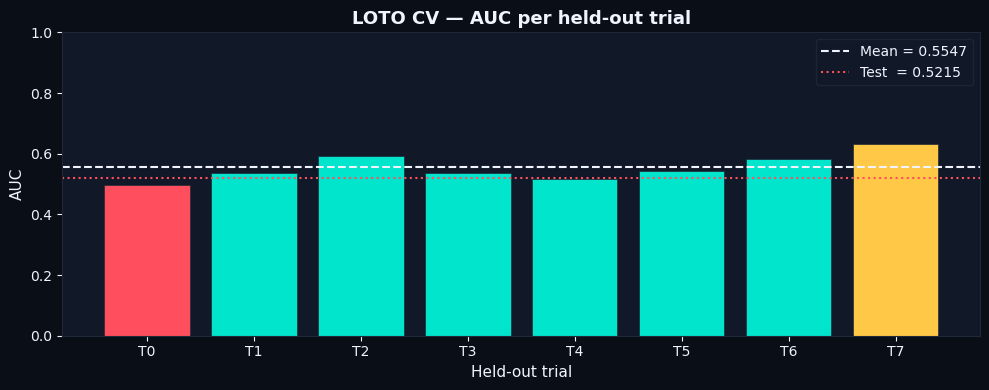

In [13]:
%matplotlib inline
# ── A: LOTO AUC per held-out trial ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)

bar_colours = [
    GOLD if v == max(loto_aucs) else CORAL if v == min(loto_aucs) else TEAL
    for v in loto_aucs
]
ax.bar(TRAIN_TRIALS, loto_aucs, color=bar_colours, edgecolor=EDGE, linewidth=0.5)
ax.axhline(
    np.mean(loto_aucs),
    color=WHITE,
    lw=1.5,
    ls="--",
    label=f"Mean = {np.mean(loto_aucs):.4f}",
)
ax.axhline(auc_test, color=CORAL, lw=1.5, ls=":", label=f"Test  = {auc_test:.4f}")
ax.set_xticks(TRAIN_TRIALS)
ax.set_xticklabels([f"T{t}" for t in TRAIN_TRIALS], color=WHITE)
ax.set_ylabel("AUC", color=WHITE, fontsize=11)
ax.set_xlabel("Held-out trial", color=WHITE, fontsize=11)
ax.set_title(
    "LOTO CV — AUC per held-out trial", color=WHITE, fontsize=13, fontweight="bold"
)
ax.tick_params(colors=WHITE)
ax.set_ylim(0, 1)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=10)
plt.tight_layout()
plt.show()

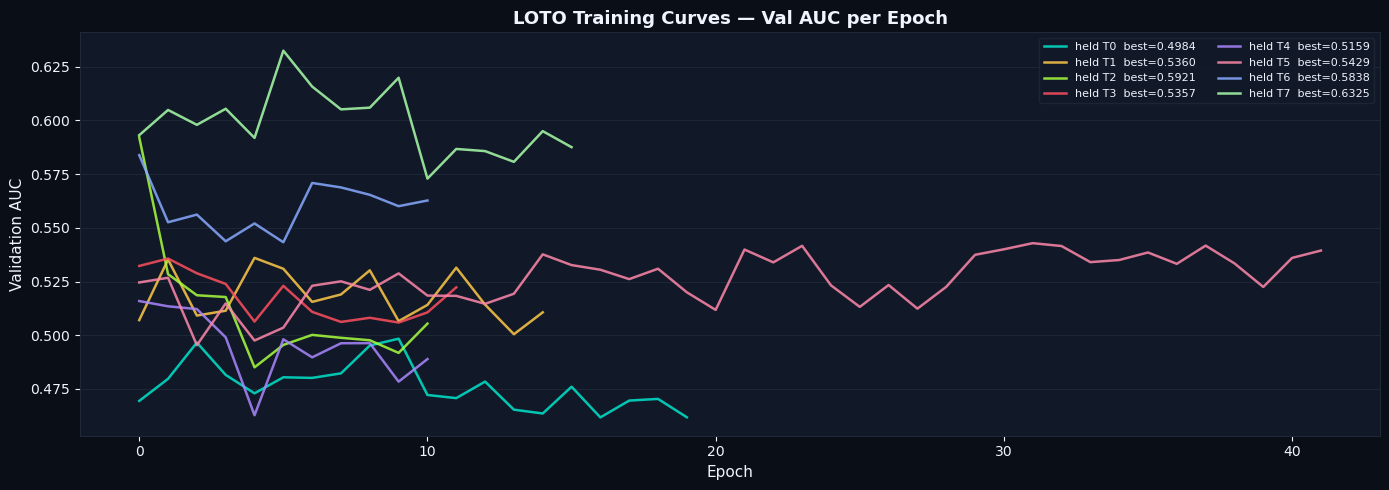

In [14]:
# ── B: Per-fold LOTO training curves ─────────────────────────────────────
fold_colors = [TEAL, GOLD, LIME, CORAL, "#aa88ff", "#ff88aa", "#88aaff", "#aaffaa"]
fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)

for fi, (hist, t) in enumerate(zip(train_hists, TRAIN_TRIALS)):
    ax.plot(
        hist,
        color=fold_colors[fi],
        lw=1.8,
        alpha=0.85,
        label=f"held T{t}  best={max(hist):.4f}",
    )

ax.set_xlabel("Epoch", color=WHITE, fontsize=11)
ax.set_ylabel("Validation AUC", color=WHITE, fontsize=11)
ax.set_title(
    "LOTO Training Curves — Val AUC per Epoch",
    color=WHITE,
    fontsize=13,
    fontweight="bold",
)
ax.tick_params(colors=WHITE)
ax.yaxis.grid(True, color=EDGE, lw=0.6)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

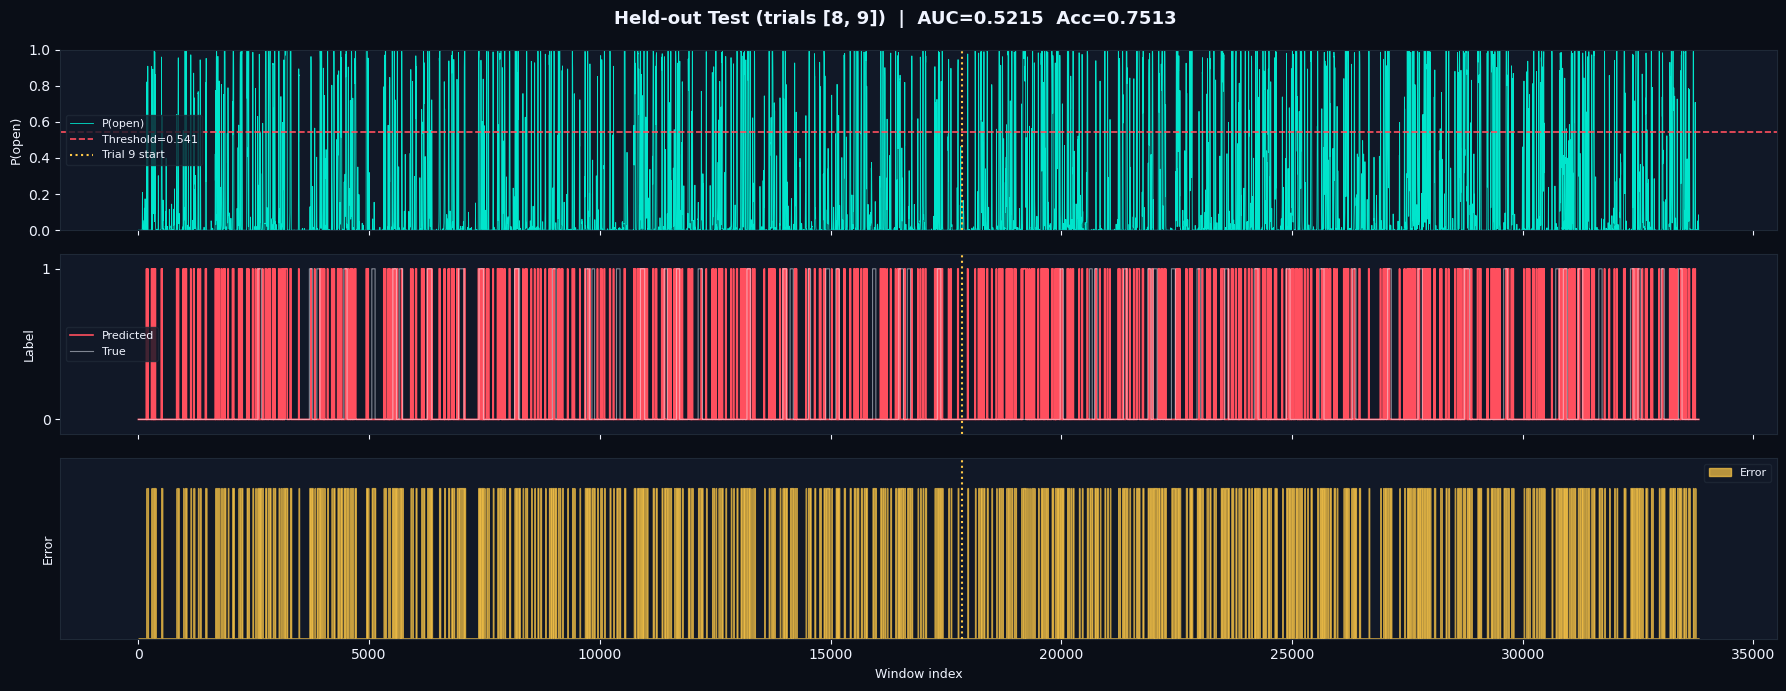

In [15]:
# ── C: Test probability timeline + true labels ────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 7), sharex=True, facecolor=DARK)
t_ax = np.arange(len(probs_test))
split = int((g_win_test == TEST_TRIALS[0]).sum())

ax = axes[0]
ax.set_facecolor(CARD)
ax.plot(t_ax, probs_test, color=TEAL, lw=0.6, label="P(open)")
ax.axhline(
    best_thresh, color=CORAL, lw=1.2, ls="--", label=f"Threshold={best_thresh:.3f}"
)
ax.axvline(split, color=GOLD, lw=1.5, ls=":", label=f"Trial {TEST_TRIALS[1]} start")
ax.set_ylim(0, 1)
ax.set_ylabel("P(open)", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values():
    sp.set_color(EDGE)

ax = axes[1]
ax.set_facecolor(CARD)
ax.plot(
    t_ax, preds_test, drawstyle="steps-post", color=CORAL, lw=1.2, label="Predicted"
)
ax.plot(
    t_ax,
    y_win_test,
    drawstyle="steps-post",
    color=WHITE,
    lw=0.8,
    alpha=0.5,
    label="True",
)
ax.axvline(split, color=GOLD, lw=1.5, ls=":")
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0, 1])
ax.set_ylabel("Label", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values():
    sp.set_color(EDGE)

ax = axes[2]
ax.set_facecolor(CARD)
errors = (preds_test != y_win_test).astype(float)
ax.fill_between(t_ax, errors, color=GOLD, alpha=0.7, step="post", label="Error")
ax.axvline(split, color=GOLD, lw=1.5, ls=":")
ax.set_ylim(0, 1.2)
ax.set_yticks([])
ax.set_ylabel("Error", color=WHITE, fontsize=9)
ax.set_xlabel("Window index", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values():
    sp.set_color(EDGE)

fig.suptitle(
    f"Held-out Test (trials {TEST_TRIALS})  |  AUC={auc_test:.4f}  Acc={acc_test:.4f}",
    color=WHITE,
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

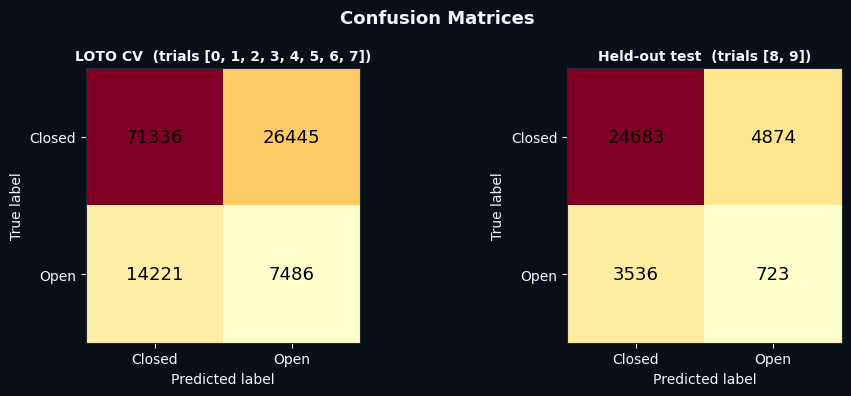

In [16]:
# ── D: Confusion matrices — LOTO vs Test ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor=DARK)
for ax, y_true, y_pred, title in [
    (axes[0], y_win[mask], preds_opt, f"LOTO CV  (trials {TRAIN_TRIALS})"),
    (axes[1], y_win_test, preds_test, f"Held-out test  (trials {TEST_TRIALS})"),
]:
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred), display_labels=["Closed", "Open"]
    ).plot(ax=ax, colorbar=False, cmap="YlOrRd")
    ax.set_title(title, color=WHITE, fontsize=10, fontweight="bold")
    ax.tick_params(colors=WHITE)
    ax.xaxis.label.set_color(WHITE)
    ax.yaxis.label.set_color(WHITE)
    for txt in ax.texts:
        txt.set_color("black")
        txt.set_fontsize(13)

plt.suptitle("Confusion Matrices", color=WHITE, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 11 · Results Summary & Save

In [17]:
print("=" * 65)
print("  EEG Causal Conv1D — Fixed Architecture, Multi-Trial Results")
print("=" * 65)
print(f"  Train trials  : {TRAIN_TRIALS}")
print(f"  Test  trials  : {TEST_TRIALS}")
print(f"  Window T      : {T} samples  ({T/FS*1000:.0f} ms)")
print(f"  Input shape   : (batch, {N_CHANNELS}, {T})")
print()
print("  Architecture")
print(f"    n_layers    : {N_LAYERS}")
print(f"    n_filters   : {N_FILTERS}  (grow={GROW_FILTERS})")
print(f"    kernel_size : {KERNEL_SIZE}")
print(f"    dropout     : {DROPOUT}")
print(f"    activation  : {ACTIVATION}")
print(f"    batch_norm  : {USE_BN}")
print()
print(f"  LOTO AUC (outer CV) : {np.mean(loto_aucs):.4f} ± {np.std(loto_aucs):.4f}")
print(f"  Optimal threshold   : {best_thresh:.3f}")
print(f"  LOTO Acc @ thresh   : {acc_opt:.4f}")
print()
print(f"  TEST AUC     : {auc_test:.4f}")
print(f"  TEST Accuracy: {acc_test:.4f}")
print("=" * 65)

  EEG Causal Conv1D — Fixed Architecture, Multi-Trial Results
  Train trials  : [0, 1, 2, 3, 4, 5, 6, 7]
  Test  trials  : [8, 9]
  Window T      : 44 samples  (176 ms)
  Input shape   : (batch, 16, 44)

  Architecture
    n_layers    : 5
    n_filters   : 60  (grow=True)
    kernel_size : 3
    dropout     : 0.3
    activation  : relu
    batch_norm  : True

  LOTO AUC (outer CV) : 0.5547 ± 0.0416
  Optimal threshold   : 0.541
  LOTO Acc @ thresh   : 0.6597

  TEST AUC     : 0.5215
  TEST Accuracy: 0.7513


In [18]:
import json

SAVE_PATH = f"../data/subject{SUBJECT}/model_conv1d_fixed"
os.makedirs(SAVE_PATH, exist_ok=True)

torch.save(final_model.state_dict(), f"{SAVE_PATH}/eeg_conv1d_model.pt")

params_to_save = {
    "T": int(T),
    "n_channels": int(N_CHANNELS),
    "channel_names": EEG_COLS,
    "fs": int(FS),
    "n_layers": int(N_LAYERS),
    "n_filters": int(N_FILTERS),
    "kernel_size": int(KERNEL_SIZE),
    "grow_filters": bool(GROW_FILTERS),
    "dropout": float(DROPOUT),
    "activation": ACTIVATION,
    "use_bn": bool(USE_BN),
    "best_thresh": float(best_thresh),
    "per_window_norm": True,
    "loto_auc_mean": float(np.mean(loto_aucs)),
    "loto_auc_std": float(np.std(loto_aucs)),
    "test_auc": float(auc_test),
    "test_acc": float(acc_test),
    "train_trials": TRAIN_TRIALS,
    "test_trials": TEST_TRIALS,
}
with open(f"{SAVE_PATH}/eeg_conv1d_params.json", "w") as f:
    json.dump(params_to_save, f, indent=2)

print("Saved:")
print(f"  {SAVE_PATH}/eeg_conv1d_model.pt")
print(f"  {SAVE_PATH}/eeg_conv1d_params.json")
print(
    f"  thresh={best_thresh:.3f}  loto_auc={np.mean(loto_aucs):.4f}  test_auc={auc_test:.4f}"
)

Saved:
  ../data/subject0/model_conv1d_fixed/eeg_conv1d_model.pt
  ../data/subject0/model_conv1d_fixed/eeg_conv1d_params.json
  thresh=0.541  loto_auc=0.5547  test_auc=0.5215
